In [1]:
#Libraries
!pip install -q rank-bm25 nltk sentence-transformers faiss-cpu

import os
import pandas as pd
import numpy as np
import re
import nltk
import faiss

from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\monua\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
#Load Corpus
corpus_df = pd.read_csv("corpus_cleaned.csv")
queries_df = pd.read_csv("queries.csv")

doc_ids = corpus_df["doc_id"].astype(str).tolist()

In [3]:
#Text Processing 
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    tokens = text.split()
    return [stemmer.stem(t) for t in tokens if t not in stop_words]

In [4]:
# QUERY EXPANSION
def expand_query(query):
    query = query.lower()
    expansions = []

    if "simple" in query or "easy" in query:
        expansions += ["easy", "simple", "few ingredients", "basic"]

    if "quick" in query:
        expansions += ["quick", "fast", "under 30 minutes"]

    if "3 step" in query or "three step" in query:
        expansions += ["few steps", "easy steps", "simple instructions"]

    return query + " " + " ".join(expansions)

In [5]:
#BM25F
def build_bm25f_text(row):
    return (
        (str(row["Title"]) + " ") * 3 +
        (str(row["Ingredients"]) + " ") * 4 +
        (str(row["Instructions"]) + " ") * 1 +
        (str(row["Image_Name"]) + " ") * 2
    )

corpus_df["bm25f_text"] = corpus_df.apply(build_bm25f_text, axis=1)
tokenized_corpus = [preprocess(t) for t in corpus_df["bm25f_text"]]
bm25f = BM25Okapi(tokenized_corpus)

In [6]:
#Dense Retrieval
model = SentenceTransformer("all-MiniLM-L6-v2")

doc_texts = (
    corpus_df["Title"].astype(str) + " " +
    corpus_df["Ingredients"].astype(str) + " " +
    corpus_df["Instructions"].astype(str) + " " +
    corpus_df["Image_Name"].astype(str)
).tolist()

doc_embeddings = model.encode(
    doc_texts,
    normalize_embeddings=True,
    convert_to_numpy=True
)

index = faiss.IndexFlatIP(doc_embeddings.shape[1])
index.add(doc_embeddings.astype(np.float32))

In [7]:
#RRF
def get_rank_dict(doc_list):
    return {doc_id: rank for rank, doc_id in enumerate(doc_list, start=1)}

def rrf_fusion(bm25_rank, dense_rank, k=60):
    all_docs = set(bm25_rank.keys()) | set(dense_rank.keys())
    scores = {}

    for doc in all_docs:
        r1 = bm25_rank.get(doc, 9999)
        r2 = dense_rank.get(doc, 9999)
        scores[doc] = (1 / (k + r1)) + (1 / (k + r2))

    return sorted(scores.items(), key=lambda x: x[1], reverse=True)

In [8]:
# IMAGE HELPER
def get_image_path(row):
    base_path = "Food_Images"
    
    image_name = str(row["Image_Name"]).strip().lower()
    
    # Normalize filename
    for file in os.listdir(base_path):
        file_clean = file.strip().lower()
        
        if file_clean.startswith(image_name):
            return os.path.join(base_path, file)
    
    return None

In [9]:
#Hybrid Search
def hybrid_rrf_search(query, top_k=5):

    expanded_query = expand_query(query)

    # BM25F
    q_tokens = preprocess(expanded_query)
    bm25_scores = bm25f.get_scores(q_tokens)
    bm25_idx = np.argsort(-bm25_scores)
    bm25_docs = [doc_ids[i] for i in bm25_idx]
    bm25_rank = get_rank_dict(bm25_docs)

    # Dense
    q_vec = model.encode([expanded_query], normalize_embeddings=True).astype(np.float32)
    scores, indices = index.search(q_vec, len(doc_ids))
    dense_docs = [doc_ids[i] for i in indices[0]]
    dense_rank = get_rank_dict(dense_docs)

    # RRF
    fused = rrf_fusion(bm25_rank, dense_rank)

    return fused[:top_k]

🍽️ Recipe Search Engine (Hybrid IR System - Demo)

██████████████████████████████████████████████████████████████████████████████████████████
🔍 Query: q01 — "shrimp pasta garlic butter easy weeknight"
██████████████████████████████████████████████████████████████████████████████████████████

Top Results:

📊 Score: 0.02905
🍽️ Title: Pasta with Rock Shrimp, Chile, and Lemon
🥕 Ingredients: ['1/2 cup (1 stick) unsalted butter', '1/4 cup bonito flakes', '2 teaspoons dried shrimp', '12 ounces fresh or dried capellini, tagliatelle, or fettuccine, preferably egg-enriched', 'Kosher salt', '2 tablespoons olive oil', '1 red chile (such as Holl ...
📖 Instructions: Melt butter in a small saucepan over medium-low heat, then add bonito flakes; swirl butter to combine. Remove from heat and let sit 10 minutes to infuse.
Strain butter through a fine-mesh sieve into a small bowl, pressing on solids; discard bonito fl ...


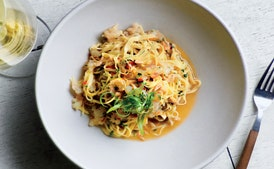


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02845
🍽️ Title: One-Pot Pasta Primavera with Shrimp
🥕 Ingredients: ['12 ounces short pasta, such as penne or fusilli', '4 garlic cloves, thinly sliced', '2 1/2 teaspoons (or more) kosher salt', '3/4 teaspoon (or more) freshly ground black pepper', '1 (10-ounce) bag frozen broccoli florets', '6 ounces green beans, pr ...
📖 Instructions: Place pasta in a large, wide-bottomed pot or large, wide, straight-sided pan. Add garlic, salt, black pepper, and 3 1/2 cups hot water. Cover and bring to a boil. Once boiling, uncover and cook, setting a timer for cooking pasta according to package  ...


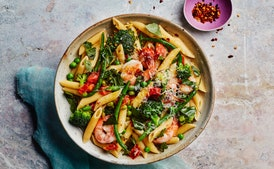


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02655
🍽️ Title: Seafood Pasta with Lemon-Saffron Herb Dressing
🥕 Ingredients: ['12 ounces campanelle (trumpet-shaped pasta) or macaroni', '1/8 teaspoon crushed saffron threads', '7 tablespoons fresh lemon juice, divided', '6 tablespoons extra-virgin olive oil, divided', '1/2 cup mayonnaise', '1/2 cup sour cream', '1/4 cup thin ...
📖 Instructions: Cook pasta in large pot of boiling salted water until tender but still firm to bite, stirring occasionally. Drain, reserving 1/2 cup cooking liquid. Place 3 tablespoons hot cooking liquid in medium bowl. Sprinkle saffron over and let stand at room te ...


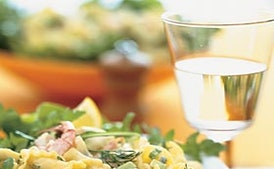


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02602
🍽️ Title: Lowcountry Breakfast Shrimp
🥕 Ingredients: ['3/4 stick unsalted butter', '2 medium onions, finely chopped', '1/2 cup thinly sliced scallion', '2 garlic cloves, finely chopped', '1 teaspoon kosher salt', '2 pound medium or large shrimp, peeled and deveined', '1/2 to 1 cup water'] ...
📖 Instructions: Heat butter in a 12-inch heavy skillet over medium heat until foaming, then cook onions with scallion, garlic, salt, and 1/4 teaspoon pepper, stirring occasionally, until softened but not browned, about 5 minutes. Add shrimp and cook, stirring, 1 min ...


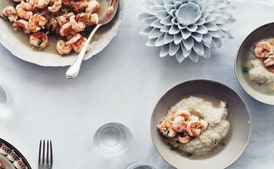


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02498
🍽️ Title: Anchovy Pasta With Garlic Breadcrumbs
🥕 Ingredients: ['8 garlic cloves, divided', '5 ounces sourdough or other crusty bread, crust removed, cut into 1-inch pieces (about 2 cups)', '1 teaspoon finely grated lemon zest', 'Kosher salt, freshly ground pepper', '1/4 cup plus 3 tablespoons (or more) olive oi ...
📖 Instructions: Very thinly slice 4 garlic cloves (a mandoline works great) and set aside. Pulse remaining 4 garlic cloves in a food processor until finely chopped. Add bread and lemon zest and pulse until coarse crumbs form; season with salt and pepper.
Heat 1/4 cu ...


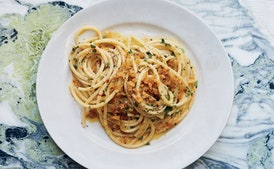


══════════════════════════════════════════════════════════════════════


██████████████████████████████████████████████████████████████████████████████████████████
🔍 Query: q02 — "quick and easy chicken garlic thyme skillet dinner with chipotle sauce"
██████████████████████████████████████████████████████████████████████████████████████████

Top Results:

📊 Score: 0.02973
🍽️ Title: Chipotle Braised Chicken
🥕 Ingredients: ['1 large onion, halved lengthwise, then thinly sliced lengthwise', '2 garlic cloves, minced', '1 Turkish or 1/2 California bay leaf', '1 tablespoon unsalted butter', '1 1/2 tablespoons olive oil, divided', '3 pounds chicken parts', '1 teaspoon chipo ...
📖 Instructions: Cook onion, garlic, and bay leaf in butter and 1/2 tablespoon oil with 1/8 teaspoon salt in a 12-inch heavy skillet over medium heat, stirring occasionally, until onion is beginning to brown, about 10 minutes. Transfer to a plate.
Pat chicken dry and ...


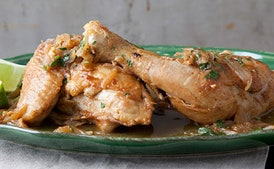


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02532
🍽️ Title: Spicy Chipotle Grilled Chicken
🥕 Ingredients: ['1/4 cup canned chipotle chiles in adobo*', '3 tablespoons olive oil', '2 garlic cloves, pressed', '1/2 onion, coarsely chopped', '2 tablespoons chopped fresh cilantro', '1 tablespoon paprika', '1 teaspoon ground cumin', '1 teaspoon chili powder', ' ...
📖 Instructions: Combine chipotles in adobo, olive oil, and garlic cloves in processor; puree until paste forms. Add chopped onion, chopped cilantro, paprika, ground cumin, chili powder, and salt; process until onion is finely chopped. Transfer 1/4 cup chipotle mixtu ...


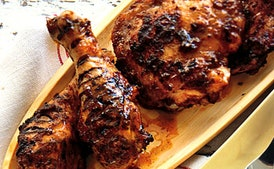


══════════════════════════════════════════════════════════════════════

📊 Score: 0.0236
🍽️ Title: Quick Chicken Tikka Masala
🥕 Ingredients: ['1 (2 1/2") piece ginger, peeled', '4 garlic cloves, peeled', '1/2 medium yellow onion', '1 1/2 pounds boneless skinless chicken breasts (about 3 breasts), cut into 1" cubes', '2 teaspoons kosher salt, divided, plus more to taste', '3/4 teaspoon fre ...
📖 Instructions: Pulse ginger and garlic in a food processor until finely chopped. Add onion and pulse again until finely chopped.
Toss chicken with 1 1/2 tsp. salt, 1/2 tsp. pepper, and 1 tsp. garam masala in a medium bowl.
Heat oil over high in a large skillet (at  ...


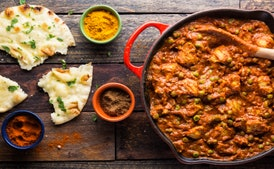


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02272
🍽️ Title: Chicken in Green Pumpkin-Seed Sauce
🥕 Ingredients: ['5 cups water', '6 chicken thighs with skin and bones', '1/4 large white onion', '3 garlic cloves, halved', '3 large fresh cilantro sprigs', '1 teaspoon fine sea salt', '1 2/3 cups shelled pepitas (pumpkin seeds)', '6 whole black peppercorns', '12 o ...
📖 Instructions: Bring all ingredients to boil in large pot. Reduce heat; simmer uncovered until chicken is cooked through, about 30 minutes. Transfer chicken to bowl; cover to keep warm. Reserve chicken broth in pot; spoon off fat from surface.
Heat heavy large skil ...


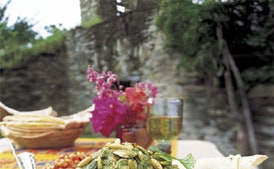


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02108
🍽️ Title: Cherry Chipotle Chili
🥕 Ingredients: ['2 tablespoons extra-virgin olive oil', '1/2 pound lean ground turkey', '3/4 teaspoon salt (preferably kosher)', '1/4 teaspoon freshly ground black pepper', '2 medium carrots, diced', '1 medium yellow onion, diced', '1 tablespoon chopped garlic', '1 ...
📖 Instructions: In a large pot, heat oil over medium-high heat. Cook turkey with salt and pepper, stirring, until browned, 5 to 10 minutes. Add carrots, onion and garlic; cook, stirring occasionally, until carrots soften, 3 to 5 minutes. Stir in chili powder. Add to ...


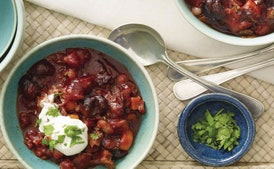


══════════════════════════════════════════════════════════════════════


██████████████████████████████████████████████████████████████████████████████████████████
🔍 Query: q03 — "sweet salmon dish with asperagus and rice or pasta"
██████████████████████████████████████████████████████████████████████████████████████████

Top Results:

📊 Score: 0.03279
🍽️ Title: Salmon with Soy-Honey and Wasabi Sauces
🥕 Ingredients: ['1/2 cupmirin (Japanese sweet rice wine)', '2 tablespoons soy sauce', '1/4 cup rice vinegar (not seasoned)', '1 tablespoon finely grated peeled fresh ginger', '4 (6-ounce) pieces salmon fillet', '2 tablespoons soy sauce', '1/4 cup honey', '1 tablesp ...
📖 Instructions: Stir together mirin, soy sauce, vinegar, and ginger in a shallow dish. Add fish, skin sides up, and marinate, covered, at room temperature 10 minutes.
Preheat broiler.
Boil soy sauce, honey, and lime juice in a small saucepan, stirring frequently, un ...


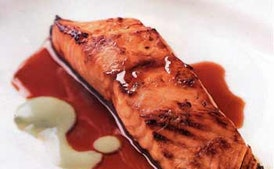


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02957
🍽️ Title: Salmon Salad with Fennel, Orange, and Mint
🥕 Ingredients: ['1/4 cup sugar', '1/4 cup unseasoned rice vinegar', '2 whole star anise*', '4 cups cold water', '1 1-pound salmon fillet with skin', '2 navel oranges', '4 cups very thinly sliced fennel (from 2 medium bulbs)', '1 cup small fresh mint leaves', '2 tab ...
📖 Instructions: Place sugar, vinegar, star anise, and 4 cups cold water in large deep skillet. Season with salt and pepper. Bring to boil over high heat, stirring until sugar dissolves. Add salmon fillet, skin side up, to skillet. Cover skillet and remove from heat. ...


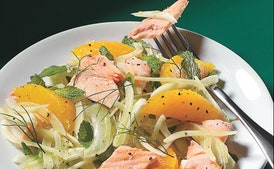


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02778
🍽️ Title: Salmon Teriyaki
🥕 Ingredients: ['1/2 cup sake', '1/4 cup mirin (sweet Japanese rice wine)', '1/4 cup soy sauce', '1 tablespoon vegetable oil, plus more if needed', '4 (6-ounce) skin-on, boneless salmon fillets (about 1 inch thick)', 'Kosher salt', 'Sansho powder (for serving; opti ...
📖 Instructions: Combine sake, mirin, and soy sauce in a small bowl; set teriyaki sauce aside.
Heat oil in a large skillet over medium-high. Season salmon lightly with salt. Cook, skin side down, until skin is brown and crisp, about 4 minutes. Turn and cook until oth ...


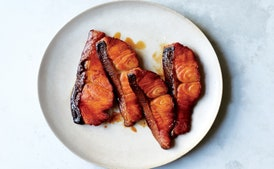


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02655
🍽️ Title: Rice Balls With Salmon Filling (Onigiri)
🥕 Ingredients: ['1 teaspoon salt', '1 cup warm cooked rice', '4 teaspoons cooked flaked fresh salmon or flaked canned salmon', '2 sheets yakinori, halved'] ...
📖 Instructions: In a shallow bowl, dissolve the salt in 1 cup water. Dip your hands into the salted water, then grab 1/4 cup of the rice. Using your hands, shape the rice into a small, fat triangle, then use your thumb to create an indentation in the center. Place a ...


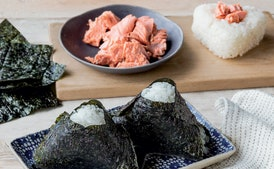


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02605
🍽️ Title: Cured Salmon with Fennel and Carrot Salad
🥕 Ingredients: ['1 1/4 cups kosher salt', '1/2 cup sugar', '1/2 cup chopped fennel fronds', '1/4 cup gin or aquavit', '1 1 1/2-pound piece skin-on salmon fillet', '2 medium carrots, peeled, very thinly sliced', '1 medium fennel bulb, very thinly sliced, plus 1 tabl ...
📖 Instructions: Mix salt, sugar, fennel fronds, and gin in a medium bowl (mixture should feel like wet sand). Spread half of salt mixture in a shallow baking dish. Place salmon on top and cover with remaining salt mixture.
Press a sheet of plastic wrap over salmon a ...


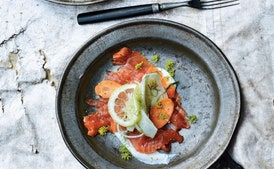


══════════════════════════════════════════════════════════════════════


██████████████████████████████████████████████████████████████████████████████████████████
🔍 Query: q04 — "gluten free recipes for sensitive stomachs"
██████████████████████████████████████████████████████████████████████████████████████████

Top Results:

📊 Score: 0.03126
🍽️ Title: Jeanne's Gluten-Free All-Purpose Flour
🥕 Ingredients: ['1 1/4 cups/170 grams brown rice flour', '1 1/4 cups/205 grams white rice flour', '1 cup/165 grams sweet rice flour', '1 cup/120 grams tapioca flour', 'scant 2 tsp xanthan gum'] ...
📖 Instructions: In a large bowl, whisk together the brown and white rice flours, sweet rice flour, tapioca flour, and xanthan gum thoroughly. Transfer the mix to an airtight container. Store in a cool, dark place for up to 6 weeks or in the refrigerator for up to 4  ...


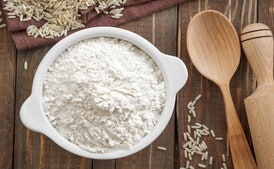


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02942
🍽️ Title: Gluten-Free Banana-Almond Pancakes with Date Caramel
🥕 Ingredients: ['1 cup chopped pitted dates', '1/4 teaspoon pure vanilla extract', 'Pinch of salt', '2 ripe bananas, peeled', '1 cup whole milk, warmed', '2 large eggs', '1/2 teaspoon vanilla extract', '1 1/2 cups almond meal (ground almonds)', '3/4 cup brown rice  ...
📖 Instructions: Soak chopped dates in 1 cup hot water for 15 minutes. Transfer dates and their soaking liquid to a blender or food processor; add vanilla extract and salt. Blend until date mixture reaches a caramel-like consistency, adding a bit more hot water if ne ...


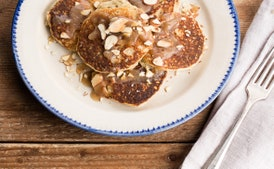


══════════════════════════════════════════════════════════════════════

📊 Score: 0.0242
🍽️ Title: Gluten-Free Coconut Layer Cake
🥕 Ingredients: ['3 cups heavy cream, chilled', '9 ounces white chocolate, coarsely chopped', '2 teaspoons coconut or golden rum', '1/8 teaspoon fine sea salt', '1 3/4 cup almond flour', '2 tablespoons coconut flour', '10 large eggs, at room temperature, separated', ...
📖 Instructions: Chill bowl of stand mixer and whisk attachment or large metal bowl and beaters for at least 15 minutes.
In small saucepan over moderate heat, bring 1 cup cream to simmer. Transfer white chocolate to medium heatproof bowl, pour hot cream over, and whi ...


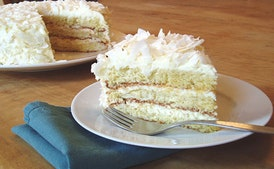


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02315
🍽️ Title: Gluten-Free Pie Crust
🥕 Ingredients: ['6 ounces bar cream cheese', '3/4 cup (1 1/2 sticks) unsalted butter', '3/4 teaspoon psyllium husk powder', '2 1/4 teaspoons whole flax seeds', '1 1/2 teaspoons whole chia seeds', '3/4 teaspoon fine sea salt', '1/2 teaspoon baking powder', '2 1/4 cu ...
📖 Instructions: Cut the cream cheese and butter into 1/2-inch pieces, place in a bowl, and freeze for 15 minutes. Use a coffee or spice grinder or mortar and pestle to grind the psyllium, flax and chia seeds to a fine powder. Transfer to the bowl of a food processor ...


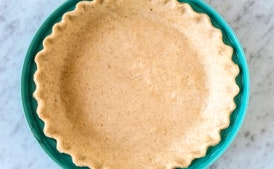


══════════════════════════════════════════════════════════════════════

📊 Score: 0.01975
🍽️ Title: No Noodle Pad Thai
🥕 Ingredients: ['1 daikon radish, peeled or zucchini', '4 carrots, peeled', '4 cups mung bean sprouts', '4 scallions, thinly sliced', '12 oz organic, GMO-free firm tofu, cut in quarters', '1 small handful cilantro leaves, chopped, plus extra for serving', '2 tables ...
📖 Instructions: Use a julienne peeler, mandoline or spiralizer (or even a potato peeler) to create noodles from the daikon and carrots. Place in a bowl and add the mung bean sprouts and onions. Add the tofu, coriander and sesame seeds to the noodles and mix. Stir to ...


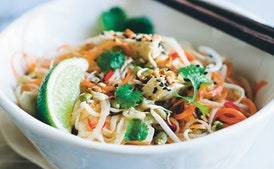


══════════════════════════════════════════════════════════════════════


██████████████████████████████████████████████████████████████████████████████████████████
🔍 Query: q05 — "potato comfort food baked cheese simple ingredients"
██████████████████████████████████████████████████████████████████████████████████████████

Top Results:

📊 Score: 0.03078
🍽️ Title: Ricotta Gnocchi with Simple Tomato Sauce
🥕 Ingredients: ['1 pound fresh ricotta cheese, drained (see Note)', '2 large egg yolks', '1 tablespoon kosher salt', '1 teaspoon freshly grated nutmeg', 'About 2 1/2 cups 00 Tipo or all-purpose flour (see Note)', '2 cups Stewed Tomatoes', '1/2 cup extra-virgin oliv ...
📖 Instructions: 1. To prepare the gnocchi, gently mix the cheese, egg yolks, salt, and nutmeg in a large bowl until blended.
2. Using your hands, fold the flour gradually into the cheese mixture. You may need more or less flour, depending on how well the cheese was  ...


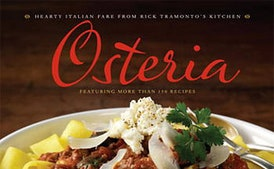


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02211
🍽️ Title: Red, White, and Blue Potato Salad
🥕 Ingredients: ['1 cup chopped green onions, divided', '1 cup sour cream', '1/2 cup mayonnaise', '1/4 cup white wine vinegar', '4 teaspoons Dijon mustard', '2 teaspoons sugar', '2 teaspoons salt', '1 teaspoon ground black pepper', '1 pound unpeeled small or baby re ...
📖 Instructions: Whisk 1/2 cup green onions and next 7 ingredients in medium bowl. Cover and chill dressing.
Do ahead: Can be made 1 day ahead. Keep chilled.
Place all potatoes in large saucepan. Add enough water to cover by 1 inch. Sprinkle with salt. Bring to boil, ...


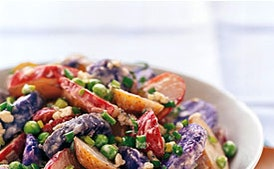


══════════════════════════════════════════════════════════════════════

📊 Score: 0.0219
🍽️ Title: Potato Stew
🥕 Ingredients: ['2 teaspoons annatto (achiote) seeds', '2 tablespoons vegetable oil', '3 1/2 lb russet (baking) potatoes', '1 cup chopped white onion', 'Rounded 1/2 teaspoon ground cumin', '2 1/4 teaspoons salt', '3/4 teaspoon black pepper', '7 cups water', '1 cup  ...
📖 Instructions: Heat annatto seeds and oil in a very small saucepan over low heat, swirling pan frequently, until oil is bright red-orange and starts to simmer, 1 to 2 minutes. Remove from heat and let stand 10 minutes.
Meanwhile, peel potatoes and cut into 3/4-inch ...


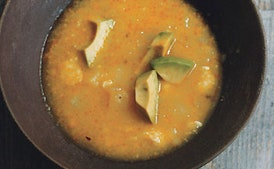


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02119
🍽️ Title: Wild Mushroom Frittata with Cheddar, Green Onions, and Peas
🥕 Ingredients: ['6 large eggs', '2 tbsp milk or water', 'Salt and freshly ground black pepper', 'Pinch of freshly grated nutmeg', 'Pinch of cayenne pepper', '2 tbsp unsalted butter', '3 new potatoes, scrubbed and cut into 1/4-in/6-mm dice', '4 green onions, white a ...
📖 Instructions: 1. Preheat the broiler with the rack in the second position from the top.
2. In a medium bowl, whisk together the eggs, milk, 1/2 tsp salt, a few grinds of pepper, the nutmeg, and cayenne.
3. In a 12-in/30.5-cm ovenproof skillet over medium-high heat ...


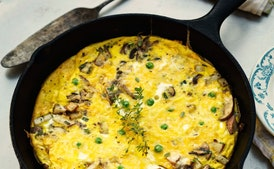


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02046
🍽️ Title: Boxty
🥕 Ingredients: ['1 egg', '1/4 cup (50ml) light (single) cream', '9 ounces (250g) baking or russet (floury) potatoes, peeled and coarsely grated', '2 tablespoons (15g) all-purpose (plain) flour', 'Salt and freshly ground black pepper', '2 tablespoons (25g) butter'] ...
📖 Instructions: In a bowl, whisk together the egg with the cream. Add the potato and flour, season with salt and pepper, and stir to mix. The mixture will be slightly runny.
Melt the butter in a frying pan over medium heat. Add the potato mixture and cook for 8 to 1 ...


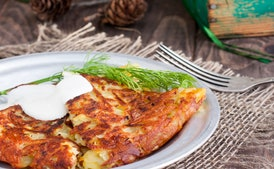


══════════════════════════════════════════════════════════════════════


██████████████████████████████████████████████████████████████████████████████████████████
🔍 Query: q06 — "creamy high carb pasta with vegetables"
██████████████████████████████████████████████████████████████████████████████████████████

Top Results:

📊 Score: 0.02789
🍽️ Title: Creamy Pasta with Crispy Mushrooms
🥕 Ingredients: ['4 Tbsp. extra-virgin olive oil', '1 lb. mixed mushrooms (such as maitake, oyster, crimini, and/or shiitake), torn into bite-size pieces', 'Kosher salt', '2 medium shallots, finely chopped', '1 lb. spaghetti or bucatini', '1/2 cup heavy cream', 'Zes ...
📖 Instructions: Heat 2 Tbsp. oil in a large pot over medium-high. Cook half of mushrooms in a single layer, undisturbed, until edges are brown and starting to crisp, about 3 minutes. Give mushrooms a toss and continue to cook, tossing occasionally, until all sides a ...


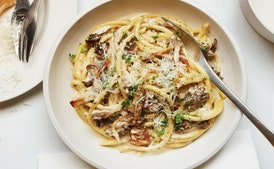


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02604
🍽️ Title: Creamy Fettuccine with Peas and Basil
🥕 Ingredients: ['3/4 cup oat milk', '1/2 cup cashew butter, at room temperature', '1 1/2 teaspoons kosher salt, divided', '1 tablespoon olive oil', '1 tablespoon chopped garlic', '1 1/2 cups frozen peas', '8 ounces whole-wheat fettuccine', '1/2 cup chopped fresh ba ...
📖 Instructions: In a bowl, whisk oat milk, cashew butter and 1/2 teaspoon salt until big lumps disappear. In a large nonstick skillet, heat oil over medium heat. Cook garlic, stirring, until golden, 1 minute. Stir in milk mixture; reduce heat to low and simmer, stir ...


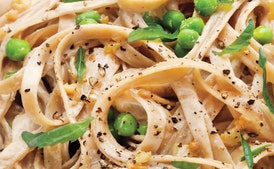


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02569
🍽️ Title: Pasta with Peas, Cream, Parsley, and Mint
🥕 Ingredients: ['1 16-ounce package large shell pasta or elbow pasta', '1 1/4 cups heavy whipping cream', '1 16-ounce package frozen petite peas (do not thaw)', '2 1/4 cups freshly grated Parmesan cheese plus additional for serving', '1/4 cup chopped fresh mint', ' ...
📖 Instructions: Cook pasta in large pot of boiling salted water until just tender but still firm to bite, stirring occasionally. Drain, reserving 1/2 cup pasta cooking liquid. Return pasta to pot.
Meanwhile, bring cream to simmer in large skillet over medium-high he ...


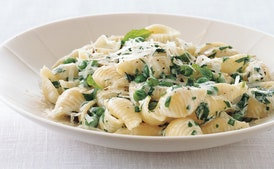


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02559
🍽️ Title: 3-Ingredient Cacio e Pepe (Pasta With Cheese and Pepper)
🥕 Ingredients: ['2 1/2 cups finely grated Pecorino Romano (about 9 ounces), plus more for serving', '2 tablespoons freshly ground black pepper, plus more for serving', '2 tablespoons extra-virgin olive oil', '1 pound spaghetti', 'Kosher salt'] ...
📖 Instructions: Combine 2 1/2 cups cheese and 2 Tbsp. pepper in a large bowl; add oil and 3/4 cup cold water and mash with a fork to make a thick paste. Spread paste evenly in bowl.
Cook pasta in a large pot of boiling salted water, stirring occasionally, until al d ...


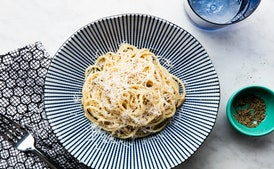


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02494
🍽️ Title: Pasta Carbonara with Cabbage and Mushrooms
🥕 Ingredients: ['1 tablespoon extra-virgin olive oil', '8 ounces shiitake mushrooms, stems removed, sliced into 1/2-inch strips', '6 ounces bacon, sliced crosswise into 1/2-inch strips', '8 ounces tagliatelle or linguine', '3/4 tsp. kosher salt, plus more', '1 medi ...
📖 Instructions: Heat oil in a large heavy skillet, preferably cast iron, over high. Cook mushrooms and bacon, stirring often, until browned and crisp, about 8 minutes. Using a slotted spoon, transfer to a paper towel-lined plate; set aside. Reserve fat in skillet.
M ...


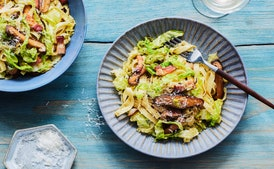


══════════════════════════════════════════════════════════════════════


██████████████████████████████████████████████████████████████████████████████████████████
🔍 Query: q07 — "protein heavy breakfast with sausage and egg"
██████████████████████████████████████████████████████████████████████████████████████████

Top Results:

📊 Score: 0.03252
🍽️ Title: Breakfast Sandwiches with Chile-Fennel Sausage Patties
🥕 Ingredients: ['1 1/2 teaspoons fennel seeds', '1 teaspoon dried oregano', '1 teaspoon red pepper flakes', '1 pound best-quality ground pork', '1/2 teaspoon sea salt', '1/2 teaspoon freshly cracked black pepper', '1 tablespoon olive oil', '4 slices Swiss cheese',  ...
📖 Instructions: Make the sausage patties: Using a mortar and pestle, smash together the fennel seeds, oregano, and red pepper flakes. In a large bowl, combine the ground pork with the spice mixture, salt, and black pepper. Give the sausage a good mix, separate it in ...


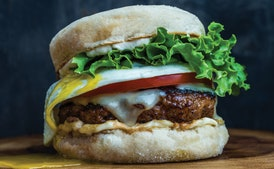


══════════════════════════════════════════════════════════════════════

📊 Score: 0.0311
🍽️ Title: Buckwheat Pancakes with Sausage, Scallions and Fried Eggs
🥕 Ingredients: ['1 cup buckwheat flour', '1 cup all-purpose flour', '2 1/2 teaspoons baking powder', '1 teaspoon salt', '1 1/2 cups whole milk', '2 large eggs, lightly beaten, plus 6 fried eggs, for serving', '3 tablespoons maple syrup', '3 tablespoons melted butte ...
📖 Instructions: In a large bowl, combine flours, baking powder, and salt. In another medium bowl, whisk together the milk, eggs, maple syrup, and melted butter. Add the wet ingredients to the dry ingredients, and stir to combine. Stir in 1/2 cup scallions.
Heat a la ...


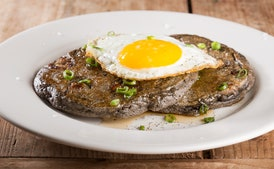


══════════════════════════════════════════════════════════════════════

📊 Score: 0.03078
🍽️ Title: Sausage Gravy
🥕 Ingredients: ['1/2 pound breakfast sausage', '1/2 cup (1 stick) unsalted butter', '1/2 cup all-purpose flour', '6 cups whole milk', '1/2 teaspoon crushed red pepper flakes', 'Kosher salt, Freshly ground pepper'] ...
📖 Instructions: Cook sausage in a medium skillet over medium heat, breaking up into small pieces with the back of a spoon, until browned and cooked through, about 5 minutes; set aside on a paper towel-lined plate to drain.
Melt butter in a large saucepan over medium ...


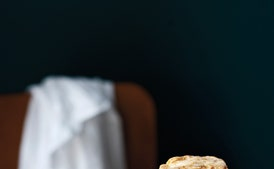


══════════════════════════════════════════════════════════════════════

📊 Score: 0.03058
🍽️ Title: Maple Andouille Breakfast Sausage
🥕 Ingredients: ['1 1/2 tablespoons paprika', '1 tablespoon finely chopped garlic', '1 tablespoon kosher salt', '1 1/2 teaspoons freshly ground black pepper', '1/2 teaspoon cayenne pepper', '1/2 teaspoon dried thyme', '1/2 teaspoon crushed red pepper flakes', '1 1/2 ...
📖 Instructions: Whisk paprika, garlic, salt, black pepper, cayenne, thyme, and red pepper flakes in a large bowl. Add pork and maple syrup. Using your hands, combine well.
Form 16 (2"-wide) patties about 1/2" thick with damp hands and arrange on a large parchment-li ...


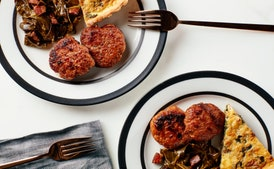


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02854
🍽️ Title: Egg and Merguez Wraps
🥕 Ingredients: ['8 large eggs', '1 cup plain whole-milk Greek yogurt', '2 Tbsp. fresh lemon juice', '1 garlic clove, finely grated', 'Kosher salt', '2 Tbsp. extra-virgin olive oil', '1 lb. merguez sausage, casings removed', '4 lavash or large flour tortillas', '1/2 ...
📖 Instructions: Bring a medium pot of water to a boil. Carefully slip in eggs and cook 8 minutes. Transfer to a bowl of ice water with a slotted spoon; let cool. Peel eggs, then slice each crosswise into 5 pieces.
Meanwhile, mix yogurt, lemon juice, and garlic in a  ...


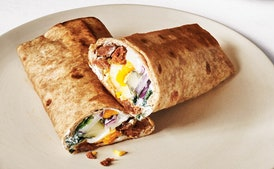


══════════════════════════════════════════════════════════════════════


██████████████████████████████████████████████████████████████████████████████████████████
🔍 Query: q08 — "strawberry or banana  based sweet treats"
██████████████████████████████████████████████████████████████████████████████████████████

Top Results:

📊 Score: 0.03058
🍽️ Title: Fruit Smoothie
🥕 Ingredients: ['2 peaches, peeled, halved, pitted', '1 grapefruit, peeled, quartered', '1 orange, peeled, halved', '1 very ripe frozen banana, peeled, chopped', '8 strawberries, hulled', '1/2 cup plain whole-milk yogurt', '1 tablespoon agave syrup (nectar)', '**In ...
📖 Instructions: Combine all ingredients in a blender and process until very smooth, about 45 seconds. Divide among glasses. ...


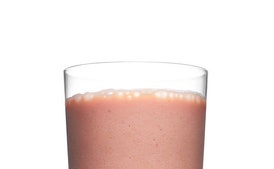


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02908
🍽️ Title: Strawberries with Marsala
🥕 Ingredients: ['2 lb strawberries (2 qt), trimmed, halved if large', '1/4 cup sugar', '1/4 cup sweet Marsala wine'] ...
📖 Instructions: Toss together strawberries, sugar, and Marsala until sugar is dissolved.
Let macerate at room temperature, tossing occasionally, 30 minutes before serving. ...


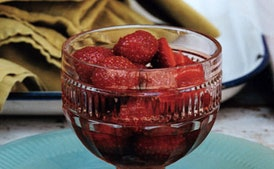


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02703
🍽️ Title: Sweet Peach Smoothie
🥕 Ingredients: ['1 1/2 cups apple juice', '1 ripe peach, peeled, pitted, and chopped (about 3/4 cup)', '3/4 ripe banana, peeled and chopped', '1 tablespoon vanilla yogurt', '6 ice cubes', '2 teaspoons honey', '2 teaspoons flaxseed oil'] ...
📖 Instructions: Combine the apple juice, peach, banana, yogurt, and ice in a blender and puree until smooth. Add the honey and flaxseed oil and puree briefly to incorporate.
Pour into glasses and serve right away. ...


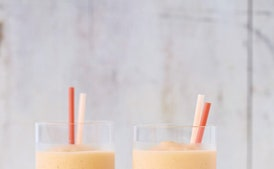


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02679
🍽️ Title: Chocolate Banana Bites
🥕 Ingredients: ['2 bananas', '1/2 cup semi-sweet chocolate morsels', '1/2 cup nuts (peanuts, almonds, cashews, etc)'] ...
📖 Instructions: Chop the banana into 1-inch thick slices.
Place the chocolate morsels in the microwave for about 50 seconds, until melted and smooth.
Finely chop the nuts.
Dip the banana slices in the the melted chocolate, then the chopped nuts, and place on a dish  ...


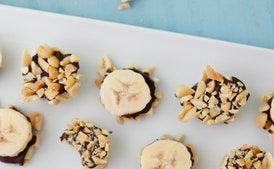


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02674
🍽️ Title: Peanut Butter and Jelly Smoothie
🥕 Ingredients: ['10 ounces unsweetened almond milk', '1 scoop vanilla Tone It Up Protein', '1/2 cup frozen strawberries', '1/2 frozen banana', '1 tablespoon peanut butter'] ...
📖 Instructions: In a high-speed blender, blend all the ingredients until the mixture is smooth and enjoy! ...


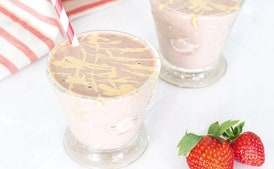


══════════════════════════════════════════════════════════════════════


██████████████████████████████████████████████████████████████████████████████████████████
🔍 Query: q09 — "simple ground beef based dinner with garlic and onion"
██████████████████████████████████████████████████████████████████████████████████████████

Top Results:

📊 Score: 0.03227
🍽️ Title: Hummus Dinner Bowls with Spiced Ground Beef and Tomatoes
🥕 Ingredients: ['1 Tbsp. vegetable oil', '1 lb. ground beef', '1 tsp. ground coriander', '1/2 tsp. freshly ground black pepper', '1/2 tsp. ground cinnamon', '2 tsp. kosher salt, divided', '1 pint cherry tomatoes or 2 medium heirloom or beefsteak tomatoes, cut into  ...
📖 Instructions: Heat oil in a large heavy, preferably cast-iron, skillet over high. Pat beef dry with paper towels, then press into an even layer in skillet with a spatula. Season with coriander, pepper, cinnamon, and 1 tsp. salt and cook, undisturbed, until a brown ...


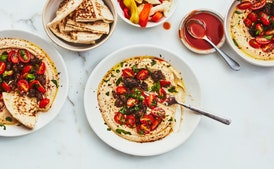


══════════════════════════════════════════════════════════════════════

📊 Score: 0.03202
🍽️ Title: Ground Beef Tacos
🥕 Ingredients: ['1 tablespoon vegetable oil', '1/2 onion, chopped', '1/2 pound ground beef or vegetarian substitute, such as Lightlife Plant-Based Ground', '1 garlic clove, minced', '1 serrano chile, stemmed and chopped', '1/2 teaspoon salt', '1 teaspoon chili powd ...
📖 Instructions: Heat the oil in a skillet over medium-high heat and cook the onion until it begins to wilt, about 2 minutes. Add the meat and sear, chopping with a spatula into small pieces until the pink color is gone. Add the garlic and chile and cook for 2 minute ...


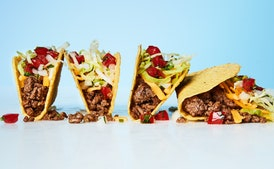


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02967
🍽️ Title: Pasta With 15-Minute Meat Sauce
🥕 Ingredients: ['1 pound pasta', 'Kosher salt', '1 medium onion, peeled, quartered', '1 celery stalk, quartered', '1 small carrot, peeled, quartered', '2 garlic cloves, peeled', '2 tablespoons olive oil', '1/2 pound ground beef or vegetarian substitute such as Ligh ...
📖 Instructions: Cook pasta in a large pot of boiling salted water, stirring occasionally, until al dente; drain and transfer to a large bowl.
Meanwhile, process onion, celery, carrot, and garlic in a food processor until finely chopped.
Heat oil in a large skillet o ...


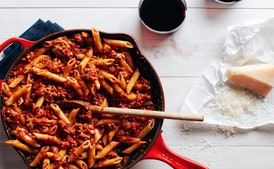


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02393
🍽️ Title: Easy Cheesy Meatballs
🥕 Ingredients: ['3 tablespoons Italian-seasoned tomato paste', '3 tablespoons full-bodied red wine, such as a California Zinfandel', '2 teaspoons Red wine vinegar', '1 1/4 pounds lean ground beef, preferably 93% lean', '3 ounces (about 3/4 cup) provolone cheese, fi ...
📖 Instructions: 1 Whisk the tomato paste, wine, and vinegar in a shallow bowl.
2 Mix the ground beef, cheese, rice, oregano, thyme, and fennel seeds in a large bowl until the cheese and seasonings are evenly distributed throughout the ground beef.
3 Form the mixture ...


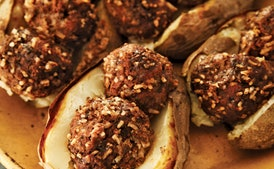


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02194
🍽️ Title: Hamburger Soup
🥕 Ingredients: ['2 1/2 pounds ground chuck or other ground beef', '1 large yellow onion, diced', '2 celery stalks, diced', '3 garlic cloves, minced', '1 (14.5-ounce can) whole tomatoes', '1 yellow bell pepper, seeded and diced', '1 red bell pepper, seeded and diced ...
📖 Instructions: 1. In a large pot, combine the meat, onion, celery, and garlic. Cook the mixture over medium-high heat until the meat is totally browned, then drain off and discard as much fat as you can.
2. Add the tomatoes and their juices, bell peppers, and carro ...


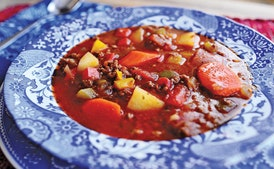


══════════════════════════════════════════════════════════════════════


██████████████████████████████████████████████████████████████████████████████████████████
🔍 Query: q10 — "one-pot chicken coconut curry rice mild creamy dishes"
██████████████████████████████████████████████████████████████████████████████████████████

Top Results:

📊 Score: 0.0315
🍽️ Title: Chicken and Green Bean Coconut Curry
🥕 Ingredients: ['2 tablespoons tamarind (not concentrate) from a pliable block', '1/2 cup boiling-hot water', '2 tablespoons coriander seeds', '1 1/2 teaspoons cumin seeds', '27 fresh curry leaves*', '6 (3-inch-long) dried hot Indian red chiles', '6 chicken breast  ...
📖 Instructions: Break up tamarind, then add to boiling-hot water (1/2 cup) in a heatproof bowl and soak 15 minutes. Mash tamarind with a fork until pulp is dissolved, then pour tamarind mixture through a fine-mesh sieve into a small bowl, pressing hard on solids to  ...


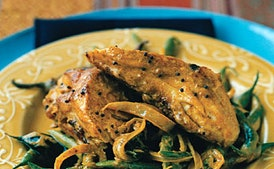


══════════════════════════════════════════════════════════════════════

📊 Score: 0.03101
🍽️ Title: Chicken Curry
🥕 Ingredients: ['1 1/2 lb skinless boneless chicken thighs (about 3 to 4)', '1 teaspoon salt', '2 tablespoons vegetable oil', '3 garlic cloves, smashed and chopped', '2 teaspoons curry powder (preferably Madras)', '1/4 teaspoon cayenne', '1 (13- to 14-oz) can unswe ...
📖 Instructions: Pat chicken dry and sprinkle with 1/2 teaspoon salt.
Heat oil in a 12-inch heavy skillet over moderately high heat until hot but not smoking, then brown chicken, turning over once, about 5 minutes total. Transfer chicken with tongs to a plate. Stir g ...


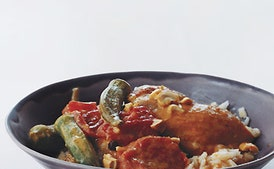


══════════════════════════════════════════════════════════════════════

📊 Score: 0.03089
🍽️ Title: Thai Chicken Curry
🥕 Ingredients: ['2 teaspoons vegetable oil', '1 4-ounce can or jar yellow curry paste', '3/4 pound carrots, peeled, cut into 1/2"-thick rounds', '1 medium onion, chopped', '1 red bell pepper, cut into 1" pieces', '1 pound Yukon Gold potatoes (about 3), peeled, cut  ...
📖 Instructions: Heat oil in a large heavy pot over medium heat. Add curry paste and cook, stirring, until fragrant, about 1 minute. Add carrots, onion, and pepper and cook, stirring occasionally, until onion is translucent, about 10 minutes.
Add potatoes, chicken, c ...


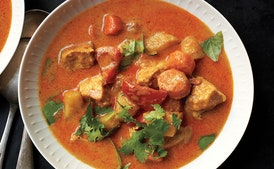


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02973
🍽️ Title: Easy Green Curry with Chicken, Bell Pepper, and Sugar Snap Peas
🥕 Ingredients: ['1 tablespoon virgin coconut or canola oil', '1/4 cup green curry paste', '1 1/2 teaspoons freshly grated ginger', '1/2 teaspoon finely grated lime zest', '1 medium onion, sliced into 1/4-inch strips', '1 teaspoon kosher salt', '1 red bell pepper, s ...
📖 Instructions: Heat oil in a medium pot over medium. Cook curry paste, ginger, and lime zest, stirring, until heated through, about 1 minute. Add onion and salt and cook, stirring, until onion is soft, about 3 minutes. Add bell pepper and stir to combine. Add chick ...


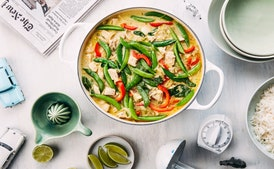


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02929
🍽️ Title: Thai Green Chicken Curry
🥕 Ingredients: ['1 tablespoon vegetable oil', '3/4 cup sliced shallots (about 5 large)', '1 3/4 teaspoons Thai green curry paste*', '1 14-ounce can unsweetened coconut milk*', '2 teaspoons fish sauce (such as nam pla or nuoc nam)*', '1 pound skinless boneless chick ...
📖 Instructions: Heat oil in large saucepan over medium heat. Add shallots and curry paste; stir until shallots soften, about 2 minutes. Add coconut milk and fish sauce; bring to boil. Add chicken and bell pepper; stir until chicken is just cooked through. Stir in ch ...


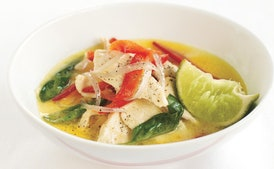


══════════════════════════════════════════════════════════════════════



In [10]:
#Test Existing Queries
from IPython.display import Image, display

print("🍽️ Recipe Search Engine (Hybrid IR System - Demo)")

for i in range(len(queries_df)):

    query_row = queries_df.iloc[i]
    query = query_row["query_text"]
    query_id = query_row["query_id"]

    print("\n" + "█"*90)
    print(f"🔍 Query: {query_id} — \"{query}\"")
    print("█"*90 + "\n")

    results = hybrid_rrf_search(query, top_k=5)

    print("Top Results:\n")

    for doc_id, score in results:

        row = corpus_df[corpus_df["doc_id"].astype(str) == str(doc_id)].iloc[0]

        print("📊 Score:", round(score, 5))
        print("🍽️ Title:", row["Title"])
        print("🥕 Ingredients:", str(row["Ingredients"])[:250], "...")
        print("📖 Instructions:", str(row["Instructions"])[:250], "...")

        img_path = get_image_path(row)

        if img_path:
            display(Image(filename=img_path, width=200))
        else:
            print("📷 Image not found:", row["Image_Name"])

        print("\n" + "═"*70 + "\n")

In [11]:
#Hybrid Eval Scores
TOP_K = 5

results_hybrid = []

for _, row in queries_df.iterrows():
    qid = row["query_id"]
    qtext = row["query_text"]

    results = hybrid_rrf_search(qtext, top_k=TOP_K)

    for rank, (doc_id, score) in enumerate(results, start=1):
        results_hybrid.append([qid, doc_id, rank, score])

run_hybrid = pd.DataFrame(
    results_hybrid,
    columns=["query_id", "doc_id", "rank", "score"]
)

run_hybrid.to_csv("run_hybrid.csv", index=False)

print("Saved: run_hybrid.csv")

Saved: run_hybrid.csv


In [12]:
#Evaluation: qrels judgement file
TOP_K = 5

qrels_rows = []

for _, qrow in queries_df.iterrows():
    qid = qrow["query_id"]
    qtext = qrow["query_text"]

    results = hybrid_rrf_search(qtext, top_k=TOP_K)

    for rank, (doc_id, score) in enumerate(results, start=1):

        row = corpus_df[corpus_df["doc_id"].astype(str) == str(doc_id)].iloc[0]

        qrels_rows.append({
            "query_id": qid,
            "query_text": qtext,
            "doc_id": doc_id,
            "rank": rank,
            "Title": row["Title"],
            "Ingredients": row["Ingredients"],
            "Instructions": row["Instructions"]
        })

qrels_pool_df = pd.DataFrame(qrels_rows)
qrels_pool_df.to_csv("qrels_pool_for_judging.csv", index=False)

print("Saved: qrels_pool_for_judging.csv")

Saved: qrels_pool_for_judging.csv


In [13]:
#Evaluation: P@5 and nDCG@5
qrels_df = pd.read_csv("qrels.csv")

#relevance lookup
rel_by_q = {}

for qid, g in qrels_df.groupby("query_id"):
    rel_by_q[str(qid)] = {
        str(r.doc_id): int(r.relevance)
        for r in g.itertuples(index=False)}

#Precision @5
def precision_at_k(ranked_doc_ids, rel_map, k=5):
    top = ranked_doc_ids[:k]

    if len(top) == 0:
        return 0.0

    hits = sum(1 for d in top if rel_map.get(str(d), 0) > 0)
    return hits / k

#nDCG@5
def dcg(rels):
    return sum(rel / np.log2(i + 2) for i, rel in enumerate(rels))

def ndcg_at_k(ranked_docs, rel_map, k=5):
    rels = [rel_map.get(str(d), 0) for d in ranked_docs[:k]]
    ideal = sorted(rel_map.values(), reverse=True)[:k]

    if sum(ideal) == 0:
        return 0.0

    return dcg(rels) / dcg(ideal)

p5_scores = []
ndcg_scores = []

print("\nHybrid IR Evaluation (P@5 + nDCG@5):")

for _, row in queries_df.iterrows():
    qid = str(row["query_id"])
    query = row["query_text"]

    results = hybrid_rrf_search(query, top_k=5)
    ranked_docs = [doc_id for doc_id, _ in results]

    rel_map = rel_by_q.get(qid, {})

    p5 = precision_at_k(ranked_docs, rel_map, k=5)
    ndcg = ndcg_at_k(ranked_docs, rel_map, k=5)

    p5_scores.append(p5)
    ndcg_scores.append(ndcg)

    print(f"{qid}: P@5={p5:.3f} | nDCG@5={ndcg:.3f}")


Hybrid IR Evaluation (P@5 + nDCG@5):
q01: P@5=0.800 | nDCG@5=0.881
q02: P@5=0.800 | nDCG@5=1.000
q03: P@5=0.600 | nDCG@5=0.912
q04: P@5=1.000 | nDCG@5=0.889
q05: P@5=0.600 | nDCG@5=0.712
q06: P@5=1.000 | nDCG@5=1.000
q07: P@5=1.000 | nDCG@5=0.979
q08: P@5=0.800 | nDCG@5=0.879
q09: P@5=1.000 | nDCG@5=0.979
q10: P@5=1.000 | nDCG@5=1.000


In [14]:
#Metric Summary

metrics_df = pd.DataFrame([
    [
        "hybrid_rrf",
        float(np.mean(p5_scores)),
        float(np.mean(ndcg_scores))
    ]
], columns=["method", "P@5", "nDCG@5"])

metrics_df.to_csv("metrics_summary.csv", index=False)

print("\nSaved: metrics_summary.csv")
print(metrics_df)


Saved: metrics_summary.csv
       method   P@5    nDCG@5
0  hybrid_rrf  0.86  0.923129


Evaluation Results Interpretation: 
-----------------------
This evaluation is based on manual scoring of the precision of the top five query results across all ten test queries. These scores were then used to compute both Precision@5 and nDCG@5. According to the metrics summary, the hybrid system (BM25F + dense retrieval + reciprocal rank fusion) performed strongly on both measures. It achieved a Precision@5 score of 0.86, indicating that on average about four out of the top five retrieved documents are relevant. Also, the system achieved a nDCG@5 score of 0.9231, which demonstrates strong ranking quality that captures semantic relevance beyond simple matching. Due to the nature of nDCG this high score indicates that the system is not only retrieving relevant results, but is also consistently ranking the most relevant documents near the top positions. Overall, this hybrid system performs very well for this domain. 

🍽️ Recipe Search Engine (Hybrid IR System)


🔍 Enter your query:  chicken and rice



Top Results:

📊 Score: 0.03252
🍽️ Title: Latin-Style Chicken and Rice
🥕 Ingredients: ['2 pounds chicken thighs with skin and bone', '2 tablespoons unsalted butter, cut into bits', '1 tablespoon olive oil', '1 large onion, chopped (2 cups)', '3 garlic cloves, minced', '1 cup medium-or long-grain white rice', '1 cup reduced-sodium chic ...
📖 Instructions: Pat chicken dry and season with 3/4 teaspoon salt and 1/2 teaspoon pepper (total). Heat butter and oil in a 12-inch heavy skillet (at least 2 inches deep) over medium-high heat until foam subsides, then brown chicken, turning once, about 10 minutes t ...


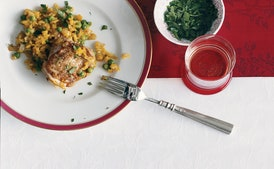


══════════════════════════════════════════════════════════════════════

📊 Score: 0.03202
🍽️ Title: Spanish-Style Chicken with Saffron Rice (Arroz con Pollo)
🥕 Ingredients: ['1 (3 1/2- to 4-lb) chicken, cut into 8 serving pieces', '1 tablespoon olive oil', '1 large onion, chopped', '1 large red bell pepper, cut into 1/2-inch pieces', '4 garlic cloves, minced', '2 teaspoons paprika', '2 cups long-grain white rice', '1 1/ ...
📖 Instructions: Pat chicken dry and season with salt and pepper. Heat oil in a 12-inch heavy skillet (at least 2 inches deep) over moderately high heat until hot but not smoking, then brown chicken on all sides, about 12 minutes total. Transfer chicken with tongs to ...


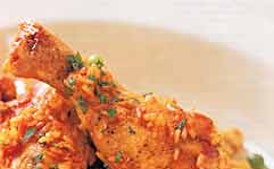


══════════════════════════════════════════════════════════════════════

📊 Score: 0.03175
🍽️ Title: Chicken & Rice Soup
🥕 Ingredients: ['low-sodium chicken broth 4 cups (32 fl oz/1 l)', 'long-grain white rice 1/3 cup (21/2 oz/75 g)', 'skinless, boneless chicken breast halves 2', 'carrot 1, peeled and diced', 'celery 1 stalk, diced', 'frozen peas 1 cup (5 oz/155 g)', 'garlic 1 clove, ...
📖 Instructions: Combine the broth, rice, and 2 cups (16 fl oz/500 ml) water in a saucepan. Place over medium heat and bring to a boil. Add the chicken to the saucepan and reduce the heat to low. Simmer the chicken, uncovered, until cooked through, 10-12 minutes. Usi ...


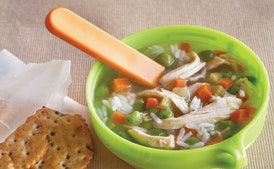


══════════════════════════════════════════════════════════════════════

📊 Score: 0.0303
🍽️ Title: Hainanese Chicken Rice
🥕 Ingredients: ['1 (3- to 3 1/2-lb) chicken', '3 teaspoons salt', '4 qt water', '4 (1/8-inch-thick) slices fresh ginger, smashed', '6 (3- to 3 1/2-inch-long) fresh hot red Thai chiles or serrano chiles, chopped', '1 shallot, chopped', '2 tablespoons chopped peeled  ...
📖 Instructions: Remove fat from cavity of chicken and reserve for rice. Rub chicken inside and out with 1 teaspoon salt.
Bring water with remaining 2 teaspoons salt and ginger to a boil in a 6- to 8-quart pot wide enough to hold chicken. Put chicken, breast down, in ...


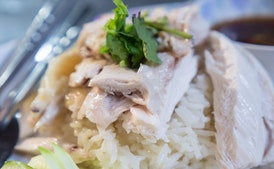


══════════════════════════════════════════════════════════════════════

📊 Score: 0.02878
🍽️ Title: Chicken Jook
🥕 Ingredients: ['1 bunch scallions', '1 (1-inch) piece fresh ginger, peeled', '12 fresh cilantro sprigs', '1 (2 1/2- to 3-lb) whole chicken', '2 teaspoons salt', '3 qt cold water', '1/4 cup dried scallops* (about 10)', '3/4 cup long-grain rice', '1/4 cup Chinese (s ...
📖 Instructions: Cut off scallion greens and reserve greens separately from white and pale green parts. Cut ginger in half crosswise and smash 1 piece with flat side of a large heavy knife, reserving remaining piece. Wrap smashed piece of ginger, cilantro, and white  ...


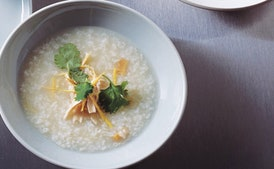


══════════════════════════════════════════════════════════════════════



In [15]:
# DEMO
from IPython.display import Image, display
print("🍽️ Recipe Search Engine (Hybrid IR System)")

query = input("🔍 Enter your query: ")

results = hybrid_rrf_search(query, top_k=5)

print("\nTop Results:\n")

for doc_id, score in results:

    row = corpus_df[corpus_df["doc_id"].astype(str) == str(doc_id)].iloc[0]

    print("📊 Score:", round(score, 5))
    print("🍽️ Title:", row["Title"])
    print("🥕 Ingredients:", str(row["Ingredients"])[:250], "...")
    print("📖 Instructions:", str(row["Instructions"])[:250], "...")

    img_path = get_image_path(row)

    if img_path:
        display(Image(filename=img_path, width=200))
    else:
        print("📷 Image not found:", row["Image_Name"])

    print("\n" + "═"*70 + "\n")